# 데이터 전처리(Data preprocessing)란

- **정의**: 데이터 분석 또는 <span style="color:red">머신러닝(ML) 모델에 적합하도록 데이터셋을 변환·조정하는 과정</span>을 말한다.
- **시점**: 데이터 분석/모델링 전에 수행하는 준비 작업.
- **원칙: *Garbage in, garbage out***

  - <span style="color:red">양질의 데이터셋으로 학습해야 예측 성능이 좋은 모델을 만들 수 있다.</span>
  - 학습용(train) 데이터의 품질은 **모델 성능에 가장 큰 영향**을 준다.

- **주요 작업 예시**

  - **데이터 정제(Data cleaning)**
    - 오류값, 이상치(outlier), 불필요한 값, 결측치(missing), 중복값 등을 식별·수정/제거.

  - **특성 선택 및 파생변수 생성(Feature selection & <span style="color:red">Feature engineering</span>)**
    - 분석에 필요한 컬럼만 선택하거나, <span style="color:red">기존 컬럼을 조합·변환해 파생변수(특성)를 생성.</span>

  - **데이터 타입 변환(Type casting)**
    - 문자열→날짜/시간(datetime), 범주형(categorical)→수치형(numeric) 등 원래 의미에 맞게 형 변환.
  - **수치형 특성 스케일링(Feature scaling)**
    - 수치형 컬럼의 척도(scale)를 맞추는 작업. 예: 표준화(Standardization, 평균 0·표준편차 1), 정규화(Normalization, [0,1] 구간 등).
  - **범주형 인코딩(Categorical encoding)**
    - 문자열 형태의 범주형 값을 숫자로 변환. 예: 원-핫 인코딩(one-hot), 순서형 인코딩(ordinal), 타깃 인코딩(target) 등.
  - **클래스 불균형**
    - 분류 문제에서 클래스의 개수의 불균형이 클 경우 <span style="color:red">적은 개수의 클래스에 대해 모델의 성능이 낮아진다.</span>
    - <span style="color:red">Over sampling</span>: 적은 클래스의 <span style="color:red">데이터를 늘려서(기존 데이터를 이용해 가짜 데이터를 생성) 수를 맞춘다.</span>
    - <span style="color:red">Under Sampling</span>: 많은 클래스의 <span style="color:red">데이터를 줄여서(삭제) 수를 맞춘다.</span>


# 결측치(Missing Value) 처리

-   결측치(Missing Value)
    -   수집하지 못한 값. 모르는 값. 없는 값
    -   결측치 값은 `NA, NaN, None, null` 로 표현한다. (언어마다 차이가 있다.)
-   <span style="color:red">결측치는</span> 데이터 분석이나 머신러닝 모델링 전의 <span style="color:red">데이터 전처리 과정에서 처리</span>해줘야 한다.


### 결측치 처리 방법

- 결측치를 다루기 전에 **이 값이 “<span style="color:red">원래 존재하지 않아서 비어 있는가</span>(구조적 결측, structural missingness)”, 아니면 “<span style="color:red">존재하지만 기록·수집에 실패해 비어 있는가</span>(관측 결측, observational missingness)”**를 <span style="color:red">먼저 구분</span>해야 한다.
    - <span style="color:red">존재하지 않아 비어 있음</span>(구조적 결측): 해당 맥락에서 값이 정의되지 않거나 적용되지 않는 경우. 이때는 임의 추정이 아니라 결측으로 유지하거나, “해당 없음(NA/Not applicable)”처럼 <span style="color:red">의미가 드러나는 표식으로 명시하는 것이 적절</span>하다.
    - <span style="color:red">기록·수집 실패로 비어 있음</span>(관측 결측): 값이 있었을 가능성이 있으나 누락된 경우. 이때는 <span style="color:red">해당 열·행의 다른 정보와 도메인 지식을 바탕으로 적절한 대체</span>(치환) 또는 모델링을 검토할 수 있다.


- #### 결측치 삭제(Complete Case Analysis):

    -   <span style="color:red">리스트와이즈 삭제(Listwise Deletion)</span>
        -   결측치가 있는 <span style="color:red">행들을 삭제</span>한다.
        -   수집한 데이터도 같이 삭제되는 단점이 있다.
        -   데이터가 충분히 크고 결측치가 많지 않을 때 적합하다.
        -   보통은 행을 삭제
    -   <span style="color:red">컬럼 삭제 (Drop column)</span>
        -   컬럼자체에 결측차가 너무 많을 경우 <span style="color:red">컬럼을 제거</span>할 수도 있다.

In [2]:
import pandas as pd
import numpy as np
data = {
    "name":['김영희', '이명수', '박진우', '이수영', '오영미'],
    "age": [23, 18, 25, 32, np.nan], 
    "weight":[np.nan, 80, np.nan, 57, 48]
}
df = pd.DataFrame(data)
df

,name,age,weight
0,김영희,23.0,NaN
1,이명수,18.0,80.0
2,박진우,25.0,NaN
3,이수영,32.0,57.0
4,오영미,NaN,48.0


In [3]:
# 결측치 확인 - 전체
df.isna().sum() # 컬럼별 결측치 개수

name      0
age       1
weight    2
dtype: int64

In [4]:
# 제거 - 행단위(리스트와즈, 0축 기준 제거: default)
df.dropna()

,name,age,weight
1,이명수,18.0,80.0
3,이수영,32.0,57.0


In [5]:
# 컬럼단위 (1축 기준 삭제)
df.dropna(axis=1)

,name
0,김영희
1,이명수
2,박진우
3,이수영
4,오영미


#### 2. 결측치 대체(imputation)

결측치가 수집하지 못해 누락된 경우 그 값일 <span style="color:red">가능성이 가장 높은 값으로 대체</span>할 수 있다.  
대체할 값으로 일정한 값을 사용하는 경우와 분석을 통해 찾는 방법이 있다.

-   **도메인 기반 처리**
-   **평균/중앙값/최빈값 대체**
    -   수치형 변수의 경우 평균이나 중앙값으로, 범주형 변수의 경우 최빈값으로 결측치를 대체한다.
    -   **평균으로 대체** - 수치형 컬럼으로 outlier(극단치)의 영향을 받지 않는 모델이거나 컬럼의 데이터들이 **정규 분포를 따르거나 outlier(극단치)가 없는 경우** 적합.
    -   **중앙값으로 대체**
        -   수치형 컬럼으로 outlier(극단치)가 존재하거나 데이터 분포가 비대칭인 컬럼의 결측치 대체에 적합.
        -   보통 평균보다 중앙값을 사용한다.
    -   **최빈값으로 대체**
        -   범주형 컬럼의 경우 대푯값인 최빈값으로 대체한다.
    
-   **모델링 기반 대체**
    -   결측치가 있는 컬럼을 output(종속변수)으로 결측치가 없는 행들(독립변수)을 input으로 하여 결측치를 예측하는 모델을 정의한다.
    -   <span style="color:red">**K-최근접 이웃(K-NN) 대체**</span>
        -   결측치가 있는 데이터 포인트와 가장 가까운 K개의 데이터 포인트를 찾아, 그 값들의 평균(수치형 데이터)이나 최빈값(범주형 데이터)으로 결측치를 대체한다.
-   **결측치를 표현하는 값으로 대체**
    -   예를 들어 나이컬럼의 nan을 -1, 혈액형의 nan을 "없음" 등과 같이 그 컬럼이 가질 수없는 값을 nan 대신 사용한다.
-   #### <span style="color:red">다중 대체 (multiple imputation)</span>
    -   <span style="color:red">여러 방식으로 결측치를 대체</span>한 데이터셋을 만든다. 각 데이터셋마다 분석하고 추론한 뒤 그 결과들을 합쳐서 최종 결론을 낸다.
    -   가장 효율적 이지만 시간이 오래 걸림


In [6]:
import pandas as pd
import numpy as np

df = pd.DataFrame([
        [0.1, 2.2, np.nan],
        [0.3, 4.1, 1], 
        [np.nan, 6, 1],
        [0.08, np.nan, 2],
        [0.12, 2.4, 1],
        [np.nan, 1.1, 3]
    ], columns=['A', 'B', 'C']
)
org = df.copy()

In [7]:
df

,A,B,C
0,0.10,2.2,NaN
1,0.30,4.1,1.0
2,NaN,6.0,1.0
3,0.08,NaN,2.0
4,0.12,2.4,1.0
5,NaN,1.1,3.0


In [8]:
df['A'].mean()

np.float64(0.15000000000000002)

In [9]:
# 컬럼별로 처리한다.
### 평균 대체
# A 열의 평균 값을 계산 하여 결측치를 대체함
df['A']  = df['A'].fillna(df['A'].mean())
df

,A,B,C
0,0.10,2.2,NaN
1,0.30,4.1,1.0
2,0.15,6.0,1.0
3,0.08,NaN,2.0
4,0.12,2.4,1.0
5,0.15,1.1,3.0


In [10]:
### 중앙값 대체
# B 열의 중앙값을 결측치에 대체함
df['B'] = df['B'].fillna(df['B'].median())
df

,A,B,C
0,0.10,2.2,NaN
1,0.30,4.1,1.0
2,0.15,6.0,1.0
3,0.08,2.4,2.0
4,0.12,2.4,1.0
5,0.15,1.1,3.0


In [11]:
### 최빈값(범주형) 대체
# C 열의 가장 많은 값으로 결측치를 대체함
df['C'] = df['C'].fillna(df['C'].mode())
df

,A,B,C
0,0.10,2.2,1.0
1,0.30,4.1,1.0
2,0.15,6.0,1.0
3,0.08,2.4,2.0
4,0.12,2.4,1.0
5,0.15,1.1,3.0


## scikit-learn 전처리기 이용한 대체

### SimpleImputer

- <span style="color:red">**SimpleImputer**</span>는 결측값을 대체하는 데 사용되는 전처리 클래스로  결측값을 <span style="color:red">평균, 중앙값, 최빈값 으로 대체</span>한다.
- **메소드**
  - **initializer** 파라미터
    - **strategy**: 어떤 값으로 대체할지 지정. "median": 중앙값, "mean": 평균, "most_frequent": 최빈값, "constant": 상수(fill_value=채울값) 중 하나 사용.
  
  
### KNNImputer
- <span style="color:red">KNN</span>(K-최근접 이웃(K-Nearest Neighbors) <span style="color:red">**머신러닝 알고리즘을 이용해 결측치를 추정해서 대체**</span>한다.
- 결측값이 있는 샘플의 최근접 이웃을 찾아 그 이웃들의 값을 평균내어 결측값을 대체한다.

#### 공통 메소드(모든 전처리기의 공통)
- <span style="color:red">fit()</span>
  - <span style="color:red">변환할 때 필요한 값들을 찾아</span>서 instance변수에 저장. (컬럼별 평균, 중앙값)
- <span style="color:red">transform()</span>
  - fit에서 찾은 값을 이용해 <span style="color:red">결측치를 대체</span>한다.
- <span style="color:red">fit_transform()</span> : fit(), transform()을 순서대로 <span style="color:red">한번에 처리.</span>

In [12]:
########################################################
# SimpleImputer 예제
########################################################
df = org.copy()

from sklearn.impute import SimpleImputer
# A, B (수치형) => 중앙값, C(범주형) => 최빈값
# 객체 생성시 어떤 방식으로 결측치를 대체할지 지정.
imputer1 = SimpleImputer(strategy="median") # 중앙값
imputer2 = SimpleImputer(strategy="most_frequent")  # 최빈값

imputer1.fit(df[['A', 'B']])  # 결측치를 어떤 값으로 바꿀지 학습. (2차원 -> 0축 기준으로 계산), 중앙값 fit으로 찾기 , 기본 적으로 2차원
result1 = imputer1.transform(df[['A', 'B']])  # 변환작업 (fit에서 찾은 중앙값으로 결측치를 대체)

result2 = imputer2.fit_transform(df['C'].to_frame()) #2차원 배열/DataFrame전달. series.to_frame() : Series->DataFrame 1차원을 2차원으로 변환
# df['c'].values.reshape(-1,1) 방식으로 2차원 변환가능
# fit/transform 을 순서대로 실행. fit/transform을 같은 데이터셋으로 할 경우 사용.

# result1, result2 하나로 합치기.
## ndarray 합치는 함수: np.concatenate([대상 배열들], axis=합칠방향(default: 0))
result = np.concatenate([result1, result2], axis=1) #[A,B] 배열과 [C] 배열을 합침
print(result.shape)
result

(6, 3)


array([[0.1 , 2.2 , 1.  ],
       [0.3 , 4.1 , 1.  ],
       [0.11, 6.  , 1.  ],
       [0.08, 2.4 , 2.  ],
       [0.12, 2.4 , 1.  ],
       [0.11, 1.1 , 3.  ]])

In [13]:
result1.shape, result2.shape

((6, 2), (6, 1))

In [14]:
########################################################
# KNNImputer 예제
########################################################
df = org.copy()
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)  # K - 가까운 데이터포인트 몇개를 확인 할지.
result = imputer.fit_transform(df)
# imputer.fit(df) -> imputer.transform(df)
print(result)

[[0.1        2.2        2.        ]
 [0.3        4.1        1.        ]
 [0.16666667 6.         1.        ]
 [0.08       2.9        2.        ]
 [0.12       2.4        1.        ]
 [0.1        1.1        3.        ]]


In [15]:
df

,A,B,C
0,0.10,2.2,NaN
1,0.30,4.1,1.0
2,NaN,6.0,1.0
3,0.08,NaN,2.0
4,0.12,2.4,1.0
5,NaN,1.1,3.0


# 이상치(Outlier) 처리

-   데이터 집합에서 다른 관측치들과 크게 다른 값을 가지는 데이터 포인트를 말한다.
    -   <span style="color:red">잘못된 값이나 극단치가 있다.</span>
-   이상치가 생기는 원인은 데이터 수집과정에서의 문제, 측정 오류, 극단적 변이가 반영된 값(엄청 튀는 값)이 수집된 경우 등이 있다.
-   이상치는 이상치들은 일반적인 경향에서 벗어난 값이므로 **정확하게 식별하고 처리하는 것이 분석의 정확성과 신뢰성을 높이는데 중요하다.**


## 분포에서 벗어난 이상치(Outlier) 식별

-   통계적 기준과 도메인 기준이 있다.

### 통계적 기준

-   **표준편차 기준**
    -   데이터가 <span style="color:red">**정규분포**</span>를 따른다고 가정할 때 <span style="color:red">평균으로 부터 _k_ 표준편차 범위 밖으로 떨어진 데이터 포인트</span>를 outlier 로 판단한다.

\begin{align}
&정상범위\,값: \mu - k \times \sigma \ \leq value \leq \mu + k \times \sigma \\
&\mu: 평균,\, \sigma: 표준편차
\end{align}

-   **분위수 기준**
    -   <span style="color:red">IQR(Inter quantile Range) 을 이용해 Outlier 여부를 찾는다.</span>
    -   1분위, 3분위 에서 IQR \* 1.5 보다 더 떨어진 값을 outlier로 판단한다. 단 정상 범위를 조정하려고 할때는 1.5값을 변경할 수 있다.

\begin{align}
&IQR = 3분위 - 1분위 \\
&정상범위\,값:  (1분위 - 1.5\times IQR) \leq value \leq  (3분위 + 1.5\times IQR)
\end{align}

-   **극단치(분포에서 벗어난 값) 처리** 
    -   정상적이 값이지만 다른 값들과 다른 패턴을 가지는 값.
    -   일반적으로 극단적으로 크거나 작은 값
    -   처리
        1. 제거한다.
            - 결측치로 대체 하거나 데이터 포인트(행)를 제거한다.
            - outlier가 분석 결과에 부정적 영향을 미치는 경우.
            - outlier값이 대상 집단을 대표하지 않는다고 판단할 경우 .
            - 명확히 잘못수집 된 오류값일 경우
        1. 윈저화 (Winsorization)
            - <span style="color:red">최소값과 최값을 정해 놓고 그 범위를 넘어서는 작은 값은 최소값으로 범위를 넘어서 큰 값은 최대값으로 대체</span>한다.
        1. 대체 (Imputation)
            - 평균, 중앙값, 최빈값 등으로 대체한다.


In [16]:
import pandas as pd
import numpy as np
np.random.seed(0)

df = pd.DataFrame(np.random.normal(10, 2, size=(10, 3)), columns=['a', 'b', 'c'])
df.iloc[[0, 3], [0, 2]] = [[100, 200],[300,-100]] # 값을 바꿈
df

,a,b,c
0,100.000000,10.800314,200.000000
1,14.481786,13.735116,8.045444
2,11.900177,9.697286,9.793562
3,300.000000,10.288087,-100.000000
4,11.522075,10.243350,10.887726
5,10.667349,12.988158,9.589683
6,10.626135,8.291809,4.894020
7,11.307237,11.728872,8.515670
8,14.539509,7.091269,10.091517
9,9.625632,13.065558,12.938718


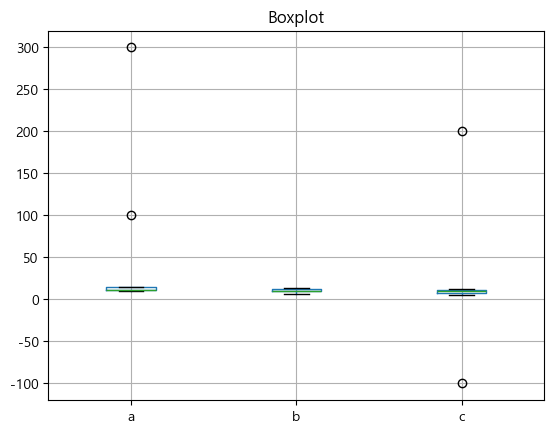

In [17]:
import matplotlib.pyplot as plt

# Boxplot을 이용해 이상치 확인
df.boxplot()
plt.title('Boxplot')
plt.show()

In [18]:
####################################################################
# # 4 분위수 기준으로 outlier를 찾기(식별)
# 1. "1분위(100분위기준 25분위), 3분위(100분위 기준 75분위)" 계산.
# 2. "IQR(Inter Quartile Range) = 3분위수 - 1분위수" 계산
# 3. "정상범위: v < 1분위값 - 1.5*iqr, v > 3분위 + 1.5*iqr" 조건으로 outlier를 찾기
####################################################################
# "a" 컬럼에서 outlier를 찾기
q1, q3 = df['a'].quantile(q=[0.25, 0.75])
iqr = q3 - q1
whis = 1.5
iqr = iqr * whis
df['a'][~df['a'].between(q1 - iqr, q3 + iqr)]  #series boolean indexing
df.loc[~df['a'].between(q1 - iqr, q3 + iqr)]

,a,b,c
0,100.0,10.800314,200.0
3,300.0,10.288087,-100.0


In [19]:
df['a'].between(10,15) # 원소 별로 10 ~ 15 사이의 값인지 여부를 체크

0    False
1     True
2     True
3    False
4     True
5     True
6     True
7     True
8     True
9    False
Name: a, dtype: bool

In [20]:
# 함수화 하기.
def find_outliers(df, column_name, whis=1.5):
    """
    분위수 기준으로 이상치를 찾는 함수

    Args:
        df (pd.DataFrame): 데이터프레임
        column_name (str): 이상치를 찾을 컬럼명

    Returns:
        pd.Series: 이상치 값들
    """
    q1, q3 = df[column_name].quantile(q=[0.25, 0.75])
    iqr = q3 - q1
    iqr *= whis

    return df.loc[~df[column_name].between(q1 - iqr, q3 + iqr), column_name]

In [21]:
find_outliers(df, 'a')
find_outliers(df, 'b')
find_outliers(df, 'c', whis=0.2)

0    200.000000
3   -100.000000
6      4.894020
9     12.938718
Name: c, dtype: float64

# Feature 타입 별 전처리

## Feature(변수)의 타입

-   **범주형(Categorical) 변수**
    -   범주를 구분하는 이름을 가지는 변수.
        -   **범주(範疇)** 의미: 동일한 성질을 가진 부류나 범위
        -   각 값 사이에 값이 없는 이산적 특징을 가진다.
        -   값이 될 수있는 값들이 정해져 있다.
    -   **명목(Norminal) 변수/비서열(Unordered) 변수**
        -   범주에 속한 값간에 서열(순위)가 없는 변수
        -   성별, 혈액형, 지역
    -   **순위(Ordinal) 변수/서열(Ordered) 변수**
        -   범주에 속한 값 간에 서열(순위)가 있는 변수
        -   성적, 직급, 만족도
-   **수치형(Numeric) 변수**
    -   수량을 표현하는 값들을 가지는 변수.
    -   <span style="color:red">**이산형(Discrete) 변수**</span>
        -   수치를 표현하지만 소수점의 형태로 표현되지 못하는 데이터. <span style="color:red">정수형 값</span>들을 가진다.
        -   예) 하루 방문 고객수, 가격(원화), 물건의 개수
    -   <span style="color:red">**연속형(Continuous) 변수**</span>
        -   수치를 표현하며 소수점으로 표현가능한 데이터. <span style="color:red">실수형 값</span>들을 가진다.
        -   예) 키, 몸무게, 시간


## 범주형 데이터 전처리

-   Scikit-learn의 머신러닝 API들은 Feature나 Label의 값들이 숫자(정수/실수)인 것만 처리할 수 있다.
-   <span style="color:red">문자열(str)일 경우 숫자 형으로 변환</span>해야 한다.
    -   **범주형 변수의 경우** 전처리를 통해 정수값으로 변환한다.
    -   범주형이 아닌 **단순 문자열인** 경우 일반적으로 제거한다.


### 범주형 Feature의 처리

-   Label Encoding
-   One-Hot Encoding


### 레이블 인코딩(Label encoding)

-   정수형 숫자로 바꾼다.
-   범주형 Feature의 고유값들 오름차순 정렬 후 0 부터 1씩 증가하는 값으로 변환
-   **숫자의 크기의 차이가 모델에 영향을 주지 않는 <span style="color:red">트리 계열 모델(의사결정나무, 랜덤포레스트)에 적용</span>한다.**
-   **숫자의 크기의 차이가 모델에 영향을 미치는 선형 계열 모델(로지스틱회귀, SVM, 신경망)에는 사용하면 안된다.**
-   트리 계열 이외에는 잘 사용 하지 않는다.

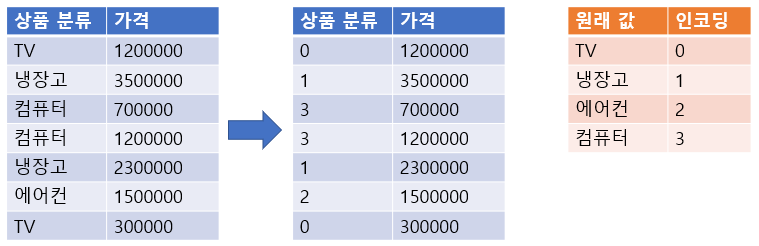


-   **sklearn.preprocessing.LabelEncoder** 사용
    -   fit(): 어떻게 변환할 지 학습
    -   transform(): 각 범주값들을 encoding 값(숫자)으로 변환
    -   fit_transform(): 학습과 변환을 한번에 처리
    -   inverse_transform(): <span style="color:red">encoding된 값을 원래 값으로 원복</span>
    -   classes\_ : 원래 값과 encoding된 값의 매핑 조회


In [22]:
import pandas as pd
# LabelEncoder는 1차원 자료구조(iterable)을 받아서 변환.
items = pd.Series(['TV', '냉장고', '컴퓨터', '컴퓨터', '냉장고', '에어콘',  'TV', '에어콘'])
items

0     TV
1    냉장고
2    컴퓨터
3    컴퓨터
4    냉장고
5    에어콘
6     TV
7    에어콘
dtype: str

In [23]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# LabelEncoder의 instance 생성
le = LabelEncoder()

# 학습: 각 고유값들을 어떤 정수로 바꿀지 계산.
le.fit(['TV', '냉장고', '컴퓨터', '에어콘', '공기 청정기', '정수기'])  # 인코딩 대상을 넣어 학습한다.

# 변환: 학습 결과에 맞춰서 값들을 변환
result1 = le.transform(items) # 찾을 대상과 변환할 대상이 다르기 때문에 fit 과 transform 을 따로 해준다
print(result1)

[0 2 5 5 2 3 0 3]


In [24]:
# 어떤 값을 어떻게 바꿨는지 조회, 값: 고유값, index: encoding 한 값
print(le.classes_)
type(le.classes_)

['TV' '공기 청정기' '냉장고' '에어콘' '정수기' '컴퓨터']


numpy.ndarray

In [25]:
print(le.classes_)
print(le.classes_[result1]) # fancy indexing

['TV' '공기 청정기' '냉장고' '에어콘' '정수기' '컴퓨터']
['TV' '냉장고' '컴퓨터' '컴퓨터' '냉장고' '에어콘' 'TV' '에어콘']


In [26]:
le.inverse_transform(result1) # 원복

array(['TV', '냉장고', '컴퓨터', '컴퓨터', '냉장고', '에어콘', 'TV', '에어콘'], dtype='<U6')

In [27]:
# fit 대상과 transform 대상이 동일한 경우. -> fit_transform() 한번에 변환.
le2 = LabelEncoder()
result2 = le2.fit_transform(items)
print(le2.classes_)
result2

['TV' '냉장고' '에어콘' '컴퓨터']


array([0, 1, 3, 3, 1, 2, 0, 2])

In [28]:
### encoding 값을 원래 값으로 원복시키기(Decoding)
le2.inverse_transform([1, 1, 1, 2, 2 ])

array(['냉장고', '냉장고', '냉장고', '에어콘', '에어콘'], dtype=object)

In [29]:
# le2.transform(['마우스', '컴퓨터']) #fit() 할 때 없는 것을 변환하면 KeyError발생.

### 원핫 인코딩(One-Hot encoding)

-   N개의 클래스를 N 차원의 <span style="color:red">One-Hot 벡터로 표현</span>되도록 변환 (밑의 그림처럼 변환하는 것이 원핫벡터)
    -   <span style="color:red">고유값들을 피처(컬럼)로 만들고 정답에 해당하는 열은 1로 나머진 0으로 표시한다</span>..
-   **숫자의 크기 차이가 모델에 영향을 미치는 선형 계열 모델(로지스틱회귀, SVM, 신경망)에서 범주형 데이터 변환시 Label Encoding보다 One Hot Encoding을 사용한다.**
-   <span style="color:red">**DecisionTree 계열의 알고리즘은 Feature에 0이 많은 경우(희소행렬:Sparse Matrix라고 한다.) 성능이 떨어지기 때문에 Label Encoding을 한다.**</span>

    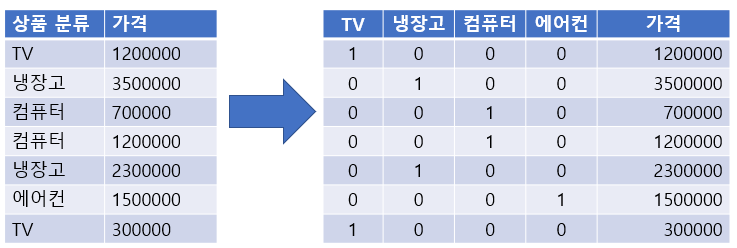


#### One-Hot Encoding 변환 처리

-   **sklearn.preprocessing.OneHotEncoder**
    -   **fit(데이터셋)**: 데이터셋을 기준으로 어떻게 변환할 지 학습
    -   **transform(데이터셋)**: Argument로 받은 데이터셋을 원핫인코딩 처리
    -   **fit_transform(데이터셋)**: 학습과 변환을 한번에 처리
    -   **get_feature_names_out()** : <span style="color:red">원핫인코딩으로 변환된 Feature(컬럼)들의 이름을 반환</span>
    -   **데이터셋은 2차원 배열을 전달 하며 Feature별로 원핫인코딩 처리한다.**
        -   DataFrame도 가능
        -   원핫인코딩 처리시 모든 타입의 값들을 다 변환한다. (연속형 값들도 변환) 그래서 변환려는 변수들만 모아서 처리해야 한다.


> OneHotEncoder객체 생성시 sparse 매개변수의 값을 False로 설정하지 않으면 scipy의 csr_matrix(희소행렬 객체)로 반환.  
> 희소행렬은 대부분 0으로 구성된 행렬과 계산이나 메모리 효율을 이용해 0이 아닌 값의 index만 관리한다.  
> csr_matrix.toarray()로 ndarray로 바꿀수 있다.


In [30]:
import numpy as np
# 원핫 인코딩은 열 단위로 처리하므로 2차원 형태의 자료구조를 입력한다.
items=np.array([['TV'],['냉장고'],['전자렌지'],['컴퓨터'],['선풍기'],['선풍기'],['믹서'],['믹서']])
print(np.shape(items)) # items.shape
items  

(8, 1)


array([['TV'],
       ['냉장고'],
       ['전자렌지'],
       ['컴퓨터'],
       ['선풍기'],
       ['선풍기'],
       ['믹서'],
       ['믹서']], dtype='<U4')

In [31]:
from sklearn.preprocessing import OneHotEncoder
# 객체 생성
ohe = OneHotEncoder()
# 학습 - 어떻게 바꿀지 학습.
ohe.fit(items)
# 변환
result = ohe.transform(items)
# ohe.fit_transform(items)

In [32]:
print(type(result))
result

<class 'scipy.sparse._csr.csr_matrix'>


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (8, 6)>

In [33]:
print(result)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (8, 6)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 4)	1.0
  (3, 5)	1.0
  (4, 3)	1.0
  (5, 3)	1.0
  (6, 2)	1.0
  (7, 2)	1.0


In [34]:
result.toarray() # ndarray로 변환.

array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.]])

In [35]:
ohe.get_feature_names_out()
# one hot encoding된 각 열(컬럼)이 어떤 class(고유값)을 나타내는지 조회.

array(['x0_TV', 'x0_냉장고', 'x0_믹서', 'x0_선풍기', 'x0_전자렌지', 'x0_컴퓨터'],
      dtype=object)

In [36]:
## 학습대상과 변환대상이 같은 경우 - fit_transform()
ohe2 = OneHotEncoder(sparse_output=False)  # ndarray로 결과를 반환.
result2  = ohe2.fit_transform(items)
result2

array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.]])

### adult dataset - one-hot encoding 적용
#### 데이터셋 소개
-   Adult 데이터셋은 1994년 인구조사 데이터 베이스에서 추출한 미국 성인의 소득 데이터셋.
-   target 은 income 이며 수입이 $50,000 이하인지 초과인지 두개의 class를 가진다.
-   https://archive.ics.uci.edu/ml/datasets/adult

#### 처리
-   범주형 컬럼을 원핫인코딩 처리한다.
-   범주형 Feature중 **income은 출력 데이터이므로 Label Encoding 처리**를 한 뒤 y로 뺀다.

In [37]:
import pandas as pd
import numpy as np

In [38]:
cols = ['age', 'workclass','fnlwgt','education', 'education-num', 'marital-status', 'occupation','relationship', 'race', 'gender','capital-gain','capital-loss', 'hours-per-week','native-country', 'income']
category_columns = ['workclass','education','marital-status', 'occupation','relationship','race','gender','native-country']
number_columns = ['age','fnlwgt', 'education-num','capital-gain','capital-loss','hours-per-week']
target = "income"

##### 데이터 로딩


In [39]:
import pandas as pd

data = pd.read_csv(
    'data/adult.data', 
    header=None,      # 첫번째 라인부터 데이터일 경우.
    names=cols,       # header(컬럼명) 지정
    na_values='?',    # 결측치로 읽을 값 설정.
    skipinitialspace=True # 값 앞의 공백을 제거하고 읽는다. , abc -> ' abc', 'abc'
)
data.shape

(32561, 15)

In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   gender          32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [41]:
data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
gender               0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [42]:
### 결측치 있는 범주형 값들 조회
data['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [43]:
data['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [44]:
data['native-country'].value_counts()

native-country
United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France                           29
Greece       

#### 결측치 처리

In [45]:
# 최빈값으로 대체 (결측치 컬럼들이 모드 범주형)
from sklearn.impute import SimpleImputer

df = data.copy()

imputer = SimpleImputer(strategy="most_frequent")
df[['workclass', 'occupation', 'native-country']] = imputer.fit_transform(df[['workclass', 'occupation', 'native-country']])

In [46]:
data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
gender               0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [47]:
data.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


#### encoding 처리
- Target(income) - Label Encoding
- Feature 중 범주형 - OneHot Encoding

In [48]:
df['income'].value_counts() # <=50k : 0 , >50k : 1 로 바꿈

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [49]:
le.fit_transform(df['income'])

array([0, 0, 0, ..., 0, 0, 1], shape=(32561,))

In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['income']) # income 을 label Encoding 한 것을 y에 할당.
np.unique(y, return_counts=True)

(array([0, 1]), array([24720,  7841]))

In [51]:
# 범위형 feature 들 원핫인코딩
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cate_features = ohe.fit_transform(df[category_columns])
#df[category_columns]

In [52]:
cate_features

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 260488 stored elements and shape (32561, 99)>

In [53]:
ohe.get_feature_names_out()

array(['workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay', 'education_10th',
       'education_11th', 'education_12th', 'education_1st-4th',
       'education_5th-6th', 'education_7th-8th', 'education_9th',
       'education_Assoc-acdm', 'education_Assoc-voc',
       'education_Bachelors', 'education_Doctorate', 'education_HS-grad',
       'education_Masters', 'education_Preschool',
       'education_Prof-school', 'education_Some-college',
       'marital-status_Divorced', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent',
       'marital-status_Never-married', 'marital-status_Separated',
       'marital-status_Widowed', 'occupation_Adm-clerical',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'o

In [54]:
# cate_features 에 수치형 컬럼 (features)의 값들을 붙인다.
# (32561, 99) (32561,6)
#df[number_columns].values
X = np.concatenate([cate_features.toarray(),df[number_columns].values],axis=1)
X.shape, df.shape

((32561, 105), (32561, 15))

In [55]:
X.shape, y.shape

((32561, 105), (32561,))

In [56]:
X[0]

array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e

In [57]:
y[0]

np.int64(0)

#### 모델링

##### train / validation / test set 분리

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=0)
X_train.shape, X_val.shape, X_test.shape

((19536, 105), (6512, 105), (6513, 105))

#####  모델링
- 모델 생성
- 학습
- 검증

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

max_depth_list = [3,4,5,6,7,8,9,10,11,12,13,14]

result_train = [] # train set 정확도 검증값들을 저장할 리스트
result_val = [] # validation set 정확도 검증값들을 저장할 리스트

for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
    # 학습(fit)
    model.fit(X_train, y_train)
    # 검증
    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    result_train.append(accuracy_score(y_train, pred_train))
    result_val.append(accuracy_score(y_val, pred_val))

In [103]:
import pandas as pd
result_df = pd.DataFrame(
    {"train_acc":result_train, "val_acc":result_val}
    , index=max_depth_list
)
result_df.rename_axis("max_depth", inplace=True)
# result_train, result_val
result_df

,train_acc,val_acc
max_depth,,
3,0.846284,0.841677
4,0.847052,0.842138
5,0.855600,0.848280
6,0.859388,0.851044
7,0.862664,0.851812
8,0.866503,0.854115
9,0.870700,0.854269
10,0.875512,0.854115
11,0.880989,0.850430


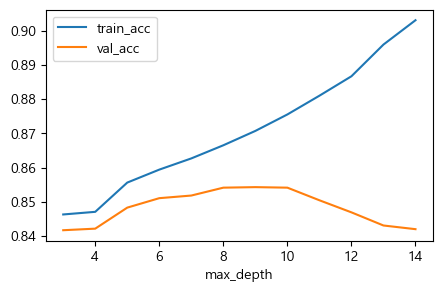

In [61]:
result_df.plot(figsize=(5,3))
plt.show()

In [62]:
result_val

[0.8416769041769042,
 0.8421375921375921,
 0.8482800982800983,
 0.851044226044226,
 0.8518120393120393,
 0.8541154791154791,
 0.8542690417690417,
 0.8541154791154791,
 0.8504299754299754,
 0.8468980343980343,
 0.8430589680589681,
 0.8419840294840295]

##### 최종평가

In [63]:
# max_depth: 9 재학습
best_model = DecisionTreeClassifier(max_depth=9, random_state=0)
best_model.fit(X_train, y_train)

pred_test = best_model.predict(X_test)
result_test = accuracy_score(y_test, pred_test)

print("테스트셋 최종 평가 결과 정확도:", result_test)

테스트셋 최종 평가 결과 정확도: 0.8529095654844158


In [64]:
##### 서비스
# 14개 feature를 입력받는다. -> 동일한 전처리 -> 모델에 입력
new_input = df.iloc[3: 7, 0:-1]
new_input.shape

(4, 14)

In [65]:
# best_model.predict(new_input)
new_input.isnull().sum() 

# 결측치가 있다면 전처리에서 사용한 SimpleImputer로 transform을 진행한다.
new_input[['workclass', 'occupation', 'native-country']] = imputer.transform(new_input[['workclass', 'occupation', 'native-country']])

In [66]:
# 범주형 컬럼 ohe 처리 - 전처리에서 학습한 OneHotEncoder 객체 이용.
new_input_cate_ohe = ohe.transform(new_input[category_columns])
new_input_cate_ohe.shape

(4, 99)

In [67]:
new_input_data = np.concatenate(
    [new_input_cate_ohe.toarray(), new_input[number_columns].values], 
    axis=1
)
new_input_data.shape

(4, 105)

In [68]:
pred = best_model.predict(new_input_data)

In [69]:
pred

array([0, 0, 1, 0])

In [70]:
le.inverse_transform(pred)

array(['<=50K', '<=50K', '>50K', '<=50K'], dtype=object)

# 수치형 데이터 전처리

-   연속형 데이터는 변수가 가지는 값들이 연속된 값인 경우로 보통 정해진 범위 안의 모든 실수가 값이 될 수 있다.

## Feature Scaling(정규화)

-   각 피처들간의 값의 <span style="color:red">범위(척도-Scale)가 다를 경우 이 값의 범위를 일정한 범위로 맞추는 작업 (예 : cm,m,km 가 있다면 km로 단위를 맞춰준다)</span>
-   트리계열을 제외한 대부분의 머신러닝 알고리즘들이 Feature간의 서로 다른 척도(Scale)에 영향을 받는다.
    -   선형모델, SVM 모델, 신경망 모델
-   **Scaling(정규화)은 train set으로 fitting 한다. test set이나 예측할 새로운 데이터는 train set으로 fitting한 것으로 변환한다.**
    -   Train Set으로 학습한 scaler를 이용해 Train/Validation/Test set들을 변환한다.
-   무조건 함

### 종류

-   표준화(Standardization) Scaling
    -   StandardScaler 사용
-   Min Max Scaling
    -   MinMaxScaler 사용


### 메소드

-   fit(): 어떻게 변환할 지 학습
    -   2차원 배열을 받으면 0축을 기준으로 학습한다. (DataFrame으로는 컬럼기준)
-   transform(): 변환
    -   2차원 배열을 받으며 0축을 기준으로 변환한다. (DataFrame으로는 컬럼기준)
-   fit_transform(): 학습과 변환을 한번에 처리
-   inverse_transform(): 변환된 값을 원래값으로 복원


## 표준화(StandardScaler)

-   피쳐의 값들이 평균이 0이고 표준편차가 1인 범위에 있도록 변환한다.
    -   0을 기준으로 모든 데이터들이 모여있게 된다

\begin{align}
&New\,x_i = \cfrac{X_i-\mu}{\sigma}\\
&\mu-평균,\; \sigma-표준편차
\end{align}

-   **sklearn.preprocessing.StandardScaler** 를 이용


In [71]:
import numpy as np
data = np.array([[10], [2], [30]])  # ndarray 생성.
print(data.shape)
data

(3, 1)


array([[10],
       [ 2],
       [30]])

In [72]:
# 평균, 표준편차 계산
m = data.mean() # 평균
s = data.std()  # 표준편차
print(m, s, sep=" --- ")

14.0 --- 11.775681155103795


In [73]:
# Standard Scaling
result = (data - m)/s
result

array([[-0.33968311],
       [-1.01904933],
       [ 1.35873244]])

In [74]:
print(result.mean(), result.std())

0.0 1.0


In [75]:
from sklearn.preprocessing import StandardScaler
# 객체 생성
s_scaler = StandardScaler()
# 어떻게 변환할지 학습 
s_scaler.fit(data) # data : 2차원, 0축 기준(컬럼)으로 처리.
# 변환
result2 = s_scaler.transform(data)
# result3 = s_scaler.fit_transform(data) # 학습/변환 대상이 같은 경우.
result2

array([[-0.33968311],
       [-1.01904933],
       [ 1.35873244]])

In [76]:
result

array([[-0.33968311],
       [-1.01904933],
       [ 1.35873244]])

## MinMaxScaler

-   <span style="color:red">데이터셋의 모든 값을 0(Min value)과 1(Max value) 사이의 값으로 변환</span>한다.
    $$
    New\,x_i = \cfrac{x_i - min(X)}{max(X) - min(X)}
    $$


##### 예제


In [77]:
data = np.array([[10], [2], [30]])
data

array([[10],
       [ 2],
       [30]])

In [78]:
minimum = data.min() #axis=0)
maximum = data.max()
print(minimum, maximum)

2 30


In [79]:
result2 = data - minimum
result2

array([[ 8],
       [ 0],
       [28]])

In [80]:
# 변환
result = (data - minimum) / (maximum - minimum)
result

array([[0.28571429],
       [0.        ],
       [1.        ]])

In [81]:
from sklearn.preprocessing import MinMaxScaler

# 객체 생성
mm_scaler = MinMaxScaler()
# 학습
mm_scaler.fit(data)
# 변환
result2 = mm_scaler.transform(data)
# result3 = mm_scaler.fit_transform(data)  # 학습/변환 대상이 같은 경우.
result2

array([[0.28571429],
       [0.        ],
       [1.        ]])

In [82]:
mm_scaler.inverse_transform(result2)

array([[10.],
       [ 2.],
       [30.]])

## 위스콘신 유방암 데이터셋으로 Scaling

-   위스콘신 대학교에서 제공한 유방암 진단결과 데이터
    -   https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original
-   Feature: 종양 측정값들
    -   모든 Feature들은 **연속형(continous)** 이다.
-   target: 악성, 양성 여부
-   scikit-learn 패키지에서 toy dataset으로 제공한다.
    -   load_breast_cancer() 함수 이용


### 데이터 로딩 및 전처리

In [83]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
feature = data['data']   # 속성 - 종양 검사 기록
target = data['target']   # 타겟 - 악성/양성 종양 여부.

feature.shape, target.shape

((569, 30), (569,))

In [84]:
data['feature_names']
data['target_names']

array(['malignant', 'benign'], dtype='<U9')

In [85]:
feature[:3]
target[:3]

array([0, 0, 0])

### Feature Scaling

In [86]:
# 전처리 전에 평균, 표준편차 확인
print(type(feature))
feature.mean(axis=0)

<class 'numpy.ndarray'>


array([1.41272917e+01, 1.92896485e+01, 9.19690334e+01, 6.54889104e+02,
       9.63602812e-02, 1.04340984e-01, 8.87993158e-02, 4.89191459e-02,
       1.81161863e-01, 6.27976098e-02, 4.05172056e-01, 1.21685343e+00,
       2.86605923e+00, 4.03370791e+01, 7.04097891e-03, 2.54781388e-02,
       3.18937163e-02, 1.17961371e-02, 2.05422988e-02, 3.79490387e-03,
       1.62691898e+01, 2.56772232e+01, 1.07261213e+02, 8.80583128e+02,
       1.32368594e-01, 2.54265044e-01, 2.72188483e-01, 1.14606223e-01,
       2.90075571e-01, 8.39458172e-02])

In [87]:
feature.std(axis=0)

array([3.52095076e+00, 4.29725464e+00, 2.42776193e+01, 3.51604754e+02,
       1.40517641e-02, 5.27663291e-02, 7.96497253e-02, 3.87687325e-02,
       2.73901809e-02, 7.05415588e-03, 2.77068942e-01, 5.51163427e-01,
       2.02007710e+00, 4.54510134e+01, 2.99987837e-03, 1.78924359e-02,
       3.01595231e-02, 6.16486075e-03, 8.25910439e-03, 2.64374475e-03,
       4.82899258e+00, 6.14085432e+00, 3.35730016e+01, 5.68856459e+02,
       2.28123569e-02, 1.57198171e-01, 2.08440875e-01, 6.56745545e-02,
       6.18130785e-02, 1.80453893e-02])

In [88]:
##### Standard Scaling Dataset 
from sklearn.preprocessing import StandardScaler

s_scaler = StandardScaler()
ss_feature = s_scaler.fit_transform(feature) # axis=0(컬럼) 기준으로 scaling


In [89]:
ss_feature.mean(axis=0)

array([-3.16286735e-15, -6.53060890e-15, -7.07889127e-16, -8.79983452e-16,
        6.13217737e-15, -1.12036918e-15, -4.42138027e-16,  9.73249991e-16,
       -1.97167024e-15, -1.45363120e-15, -9.07641468e-16, -8.85349205e-16,
        1.77367396e-15, -8.29155139e-16, -7.54180940e-16, -3.92187747e-16,
        7.91789988e-16, -2.73946068e-16, -3.10823423e-16, -3.36676596e-16,
       -2.33322442e-15,  1.76367415e-15, -1.19802625e-15,  5.04966114e-16,
       -5.21317026e-15, -2.17478837e-15,  6.85645643e-16, -1.41265636e-16,
       -2.28956670e-15,  2.57517109e-15])

In [90]:
ss_feature.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [91]:
## Min Max Scaling
# 전처리전 min 값
feature.min(axis=0)


array([6.981e+00, 9.710e+00, 4.379e+01, 1.435e+02, 5.263e-02, 1.938e-02,
       0.000e+00, 0.000e+00, 1.060e-01, 4.996e-02, 1.115e-01, 3.602e-01,
       7.570e-01, 6.802e+00, 1.713e-03, 2.252e-03, 0.000e+00, 0.000e+00,
       7.882e-03, 8.948e-04, 7.930e+00, 1.202e+01, 5.041e+01, 1.852e+02,
       7.117e-02, 2.729e-02, 0.000e+00, 0.000e+00, 1.565e-01, 5.504e-02])

In [92]:
# 전처리전 max 값
feature.max(axis=0)

array([2.811e+01, 3.928e+01, 1.885e+02, 2.501e+03, 1.634e-01, 3.454e-01,
       4.268e-01, 2.012e-01, 3.040e-01, 9.744e-02, 2.873e+00, 4.885e+00,
       2.198e+01, 5.422e+02, 3.113e-02, 1.354e-01, 3.960e-01, 5.279e-02,
       7.895e-02, 2.984e-02, 3.604e+01, 4.954e+01, 2.512e+02, 4.254e+03,
       2.226e-01, 1.058e+00, 1.252e+00, 2.910e-01, 6.638e-01, 2.075e-01])

In [93]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler()

m_fearture = mm_scaler.fit_transform(feature)

In [94]:
# 전처리 후 min 값
m_fearture.min(axis=0)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [95]:
# 전처리 후 max 값
m_fearture.max(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

### 모델 학습

In [104]:
# 모델 학습
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [105]:
import numpy as np
# Dataset 로딩
X, y = load_breast_cancer(return_X_y=True)
print(X.shape, y.shape)
print(np.unique(y, return_counts=True))

(569, 30) (569,)
(array([0, 1]), array([212, 357]))


In [ ]:
from sklearn.model_selection import train_test_split
# min, max 를 Xtrain값 으로 계산
# train / test set 분리
# 전처리 전
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)
X_train.shape, X_test.shape

((455, 30), (114, 30))

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Feature Scaling (전처리)
# Train set을 기준으로 어떻게 변환할 지 학습(fit) 하고 그것을 바탕으로 train/test/validation set을 변환한다.
# -- Data Leakage(데이터 누수) 현상 : 학습시점에 알수 없는 데이터(정보)를 활용해서 모델을 학습하여
#                                    모델의 성능이 떨어지는 현상. Train set 검증에는 좋은 성능을
#                                    보여주지만 validation, test set 에는 성능이 떨어진다.
#                                    모델에 대한 정확한 평가/검증을 하지 못한다.
# 원핫인코딩 시에도 원래는 이렇게 해야함
# 스탠다드 스케일링
s_scaler = StandardScaler()
X_train_scaled1 = s_scaler.fit_transform(X_train)
X_test_scaled1 = s_scaler.transform(X_test)
#X_test_scaled1 = s_scaler.transform(X_val)

In [ ]:
# 민맥스 스케일링
m_scaler = MinMaxScaler()
X_train_scaled2 = m_scaler.fit_transform(X_train)
X_test_scaled2 = m_scaler.transform(X_test)

In [112]:
X_train_scaled1.mean(axis=0)
X_train_scaled1.std(axis=0)
X_test_scaled1.mean(axis=0)
X_test_scaled1.std(axis=0)



array([0.8894957 , 0.93209279, 0.8926424 , 0.8352226 , 1.06062065,
       1.06795443, 1.16650413, 0.9855699 , 1.05794147, 1.05410017,
       0.85214522, 0.87531223, 0.78655963, 0.73140607, 0.86009175,
       1.20168919, 1.66326195, 1.10007363, 0.95086108, 1.65848636,
       0.91246235, 0.93609348, 0.90690064, 0.85781315, 1.01853051,
       1.05506272, 1.11803664, 0.93075875, 1.09623816, 1.09096322])

In [118]:
X_train_scaled2.min(axis=0)
X_train_scaled2.max(axis=0)

X_test_scaled2.min(axis=0)
X_test_scaled2.max(axis=0)

array([0.81096038, 0.76969902, 0.84137146, 0.6824852 , 1.23255814,
       0.8199497 , 1.13692062, 1.05175118, 0.81717172, 0.94903117,
       0.50606554, 0.60992751, 0.437874  , 0.4224857 , 0.7348472 ,
       0.78219725, 1.30348914, 1.29070905, 0.68100974, 1.37603636,
       0.72078064, 0.88992537, 0.77428702, 0.55910083, 0.78603975,
       1.13188961, 0.88258786, 1.0024113 , 0.82968658, 1.29247202])

In [124]:
######## scaling 안한 데이터로 모델링(모델 학습, 검증)
# svc1 = SVC(C=0.1, gamma=0.1, random_state=0)
svc1 = SVC(random_state=0)
svc1.fit(X_train, y_train)

pred_train1 = svc1.predict(X_train)
pred_test1 = svc1.predict(X_test)

acc_train1 = accuracy_score(y_train, pred_train1)
acc_test1 = accuracy_score(y_test, pred_test1)

print(acc_train1, acc_test1)


0.9230769230769231 0.9122807017543859


In [125]:
##### Standard Scaling 한 데이터로 모델링
# svc2 = SVC(C=0.1, gamma=0.1, random_state=0)
svc2 = SVC(random_state=0)
svc2.fit(X_train_scaled1, y_train)

pred_train2 = svc2.predict(X_train_scaled1)
pred_test2 = svc2.predict(X_test_scaled1)

acc_train2 = accuracy_score(y_train, pred_train2)
acc_test2 = accuracy_score(y_test, pred_test2)

print(acc_train2, acc_test2)


0.989010989010989 0.9649122807017544


In [ ]:
### Min Max Scaling 한 데이터로 모델링
# svc3 = SVC(C=0.1, gamma=0.1, random_state=0)
svc3 = SVC(random_state=0)
svc3.fit(X_train_scaled2, y_train) # 여기와

pred_train3 = svc3.predict(X_train_scaled2) # 여기가 같아야함
pred_test3 = svc3.predict(X_test_scaled2) # 여기다 같아야함

acc_train3 = accuracy_score(y_train, pred_train3)
acc_test3 = accuracy_score(y_test, pred_test3)

print(acc_train3, acc_test3)


0.9868131868131869 0.956140350877193


# 모델 저장 -> pickle

- <span style="color:red">전처리 객체, 모델 객체 모두 저장한다.</span>

In [130]:
import os
# 저장할 경로 생성
save_dir = "saved_model/wisconsin_breast_cancer"
os.makedirs(save_dir, exist_ok=True)

scaler_path = os.path.join(save_dir, 'standard_scaler.pkl')
model_path = os.path.join(save_dir, 'svm_model.pkl')
print(scaler_path, model_path)

saved_model/wisconsin_breast_cancer\standard_scaler.pkl saved_model/wisconsin_breast_cancer\svm_model.pkl


In [131]:
### StandardScaler 저장
import pickle

with open(scaler_path, 'wb') as fw_scaler:
    pickle.dump(s_scaler, fw_scaler)  # StandardScaler 학습

In [132]:
### 모델 저장
with open(model_path, 'wb') as fw_model:
    pickle.dump(svc2, fw_model)

In [133]:
# Scaler 모델 불러오기
with open(scaler_path, 'rb') as fr_scaler:
    saved_scaler = pickle.load(fr_scaler)
    
with open(model_path, 'rb') as fr_model:
    saved_svc = pickle.load(fr_model)

In [ ]:
#loading 한 전처리기(Scaler)와 모델을 이용해서 Test Set 추론 및 평가
x_test_scaled = saved_scaler.transform(X_test)
result = saved_svc.predict(x_test_scaled)
accuracy_score(y_test, result)

0.9649122807017544